In [ ]:
import pandas as pd

# The five simulated streams are produced by:
#   python gait_gen.py            -> sim_*.txt
#   python read_serial.py sim_walk.txt sim_walk.csv   (and so on)
df = pd.read_csv("sim_walk.csv")


In [47]:
def load_sessions(paths): # list of file paths
  frames = []
  for p in paths:
        temp_df = pd.read_csv(p)
        temp_df = temp_df.reset_index(drop=True) # Ensure a simple RangeIndex
        temp_df['ts_us'] = temp_df.index * 10000 # Add ts_us to each dataframe assuming 100Hz
        frames.append(temp_df)
  return pd.concat(frames, keys=paths)

In [ ]:
combined = load_sessions(["sim_walk.csv"])
combined.shape
combined.index[:3]


In [49]:
def clean(df):
  before = len(df)
  sensors = df[["s0","s1","s2","s3","s4","s5"]]
  ok = ((sensors >= 0) & (sensors <= 4095)).all(axis=1)
  print("dropped:", before - len(df[ok]), "of", before)
  return df[ok]



In [50]:
cleaned = clean(combined)
print(cleaned.shape)

dropped: 0 of 6000
(6000, 8)


In [51]:
import numpy as np
values = cleaned[["s0","s1","s2","s3","s4","s5"]].to_numpy()
print(values.shape)
first = values[0:100, :]
print(first.shape)

(6000, 6)
(100, 6)


In [52]:
def window(values, length, stride):
  n = (len(values) - length) // stride + 1
  out = []
  for k in range(n):
        start = k * stride
        out.append(values[start : start + length, :])
  return np.stack(out)

w = window(values, 100, 50)
print(w.shape)

(119, 100, 6)


In [53]:
sensors = cleaned[["s0","s1","s2","s3","s4","s5"]]

summary = pd.DataFrame({
    "mean": sensors.mean(),
    "peak": sensors.max(),
    "active_frac": (sensors > 100).mean(),
})

print(summary)

          mean  peak  active_frac
s0  469.040833  1951     0.399000
s1  492.813167  1557     0.533167
s2  797.923833  2144     0.600000
s3  822.982167  2251     0.600000
s4  570.437167  1843     0.515667
s5  388.058333  1655     0.382667


In [54]:
toy = cleaned.head(20)
toy.to_csv("toy.csv", index=False)

In [55]:
t = load_sessions(["toy.csv"])
t = clean(t)
tv = t[["s0","s1","s2","s3","s4","s5"]].to_numpy()
tw = window(tv, 5, 5)
print(tw.shape)

dropped: 0 of 20
(4, 5, 6)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from detector import SENSOR_COLS


def plot_session(df, flagged_times=None, title="Session"):
    t_sec = df["ts_us"] / 1e6
    fig, axes = plt.subplots(6, 1, sharex=True, sharey=True, figsize=(11, 9))
    for i, col in enumerate(SENSOR_COLS):
        ax = axes[i]
        ax.plot(t_sec, df[col], linewidth=0.8)
        ax.set_ylabel(col, rotation=0, labelpad=18, va="center")
        ax.grid(alpha=0.3)
        if flagged_times is not None:
            for ft in flagged_times:
                ax.axvline(ft, color="red", linewidth=1.0, alpha=0.7)
    axes[0].set_title(title)
    axes[-1].set_xlabel("time (s)")
    axes[-1].set_ylim(0, 4095)
    fig.tight_layout()
    return fig, axes


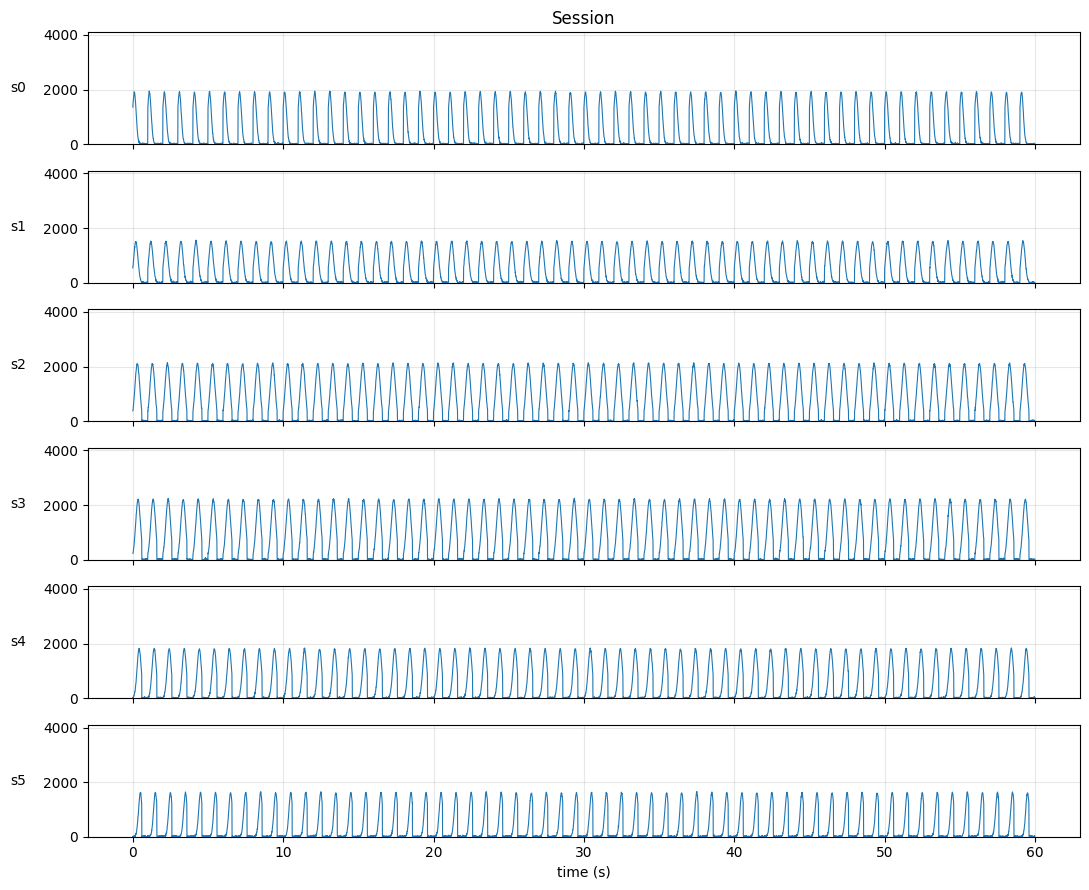

In [57]:
fig, axes = plot_session(cleaned)

In [ ]:
# find_stances used to be defined here. It now lives in detector.py so that
# test_stances.py can import the same definition -- a test cannot import a
# notebook cell, and a second copy would drift until the test passed against
# a stale detector.
#
# Constants are re-exported for the plotting cell below. All are RETUNE.
from detector import (
    find_stances, merge_close, stance_report,
    T_ON, T_OFF, MIN_DURATION, MAX_DURATION, GAP_MERGE,
)

print(f"T_ON={T_ON} T_OFF={T_OFF} MIN_DURATION={MIN_DURATION} "
      f"MAX_DURATION={MAX_DURATION} GAP_MERGE={GAP_MERGE}")


In [59]:
def plot_stances(t_sec, total, stances, xlim=None, title="Detected stances"):
    fig, ax = plt.subplots(1, 1, figsize=(11, 4))
    for (a, b) in stances:
        ax.axvspan(t_sec[a], t_sec[b], color="#1D9E75", alpha=0.18, linewidth=0)
    ax.plot(t_sec, total, linewidth=0.9, color="#378ADD")
    ax.axhline(T_ON, color="#888780", linestyle="--", linewidth=0.8)
    ax.axhline(T_OFF, color="#888780", linestyle=":", linewidth=0.8)
    ax.text(t_sec[0], T_ON, " T_ON", va="bottom", fontsize=8, color="#666")
    ax.text(t_sec[0], T_OFF, " T_OFF", va="bottom", fontsize=8, color="#666")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("total force (ADC counts)")
    ax.set_title(f"{title} - {len(stances)} stances")
    ax.grid(alpha=0.3)
    if xlim is not None:
        ax.set_xlim(*xlim)
    fig.tight_layout()
    return fig, ax

In [ ]:
t_sec = (cleaned["ts_us"] / 1e6).to_numpy()
total = values.sum(axis=1)
stances = merge_close(find_stances(total))
fig, ax = plot_stances(t_sec, total, stances, xlim=(0, 6))


In [61]:
def overlap(x, y):
    return max(0, min(x[1], y[1]) - max(x[0], y[0]) + 1)

def match_stances(detected, truth, min_overlap=0.5):
    claimed = set()
    tp = 0
    for d in detected:
        best, best_ov = None, 0
        for j, t in enumerate(truth):
            if j in claimed:
                continue
            ov = overlap(d, t)
            if ov > best_ov:
                best, best_ov = j, ov
        if best is not None and best_ov >= min_overlap * (truth[best][1] - truth[best][0] + 1):
            claimed.add(best)
            tp += 1
    fp = len(detected) - tp
    fn = len(truth) - tp
    return tp, fp, fn

def precision_recall(tp, fp, fn):
    p = tp / (tp + fp) if tp + fp else 0.0
    r = tp / (tp + fn) if tp + fn else 0.0
    return p, r


## Segmentation scorecard

Precision and recall over all five simulated streams, next to the boundary
errors that P/R cannot see.

**Read the last three columns, not the first six.** On simulated streams the
truth intervals are derived from the same constants that generated the data,
so a perfect P/R validates the *matching* code, not the detector. The mean
start / end / duration errors are the honest columns: they are what the
counts are structurally blind to, and a detector that finds every stance
while clipping 15% off each contact time still scores 1.000.

The real test is hardware data.


In [ ]:
from gait_gen import SHUFFLE_CYCLE_S, true_stances

# (csv, gait_gen mode for truth, cycle_s for truth)
STREAMS = [
    ("sim_walk.csv",    "walk",     1.0),
    ("sim_fast.csv",    "walk",     0.6),
    ("sim_shuffle.csv", "shuffle",  SHUFFLE_CYCLE_S),
    ("sim_dropout.csv", "walk",     1.0),
    ("sim_stand.csv",   "standing", 1.0),
]

rows = []
for path, mode, cycle_s in STREAMS:
    # Read directly rather than via load_sessions: that helper overwrites
    # ts_us with df.index * 10000, which would launder any real jitter.
    stream = pd.read_csv(path)
    total_force = stream[SENSOR_COLS].sum(axis=1).to_numpy()

    detected = merge_close(find_stances(total_force))
    truth = true_stances(60, mode=mode, cycle_s=cycle_s)

    tp, fp, fn = match_stances(detected, truth, min_overlap=0.5)
    p, r = precision_recall(tp, fp, fn)
    f1 = 2 * p * r / (p + r) if (p + r) else 0.0
    if not detected and not truth:
        # Correctly finding nothing in a stream that contains nothing. P/R are
        # undefined here, not zero; precision_recall returns 0.0 for the empty
        # case, which would read as a failed row for the one stream that is
        # exactly right.
        p = r = f1 = float("nan")
    rep = stance_report(detected, truth)

    rows.append({
        "stream": path.replace("sim_", "").replace(".csv", ""),
        "detected": len(detected),
        "truth": len(truth),
        "TP": tp, "FP": fp, "FN": fn,
        "P": round(p, 3), "R": round(r, 3), "F1": round(f1, 3),
        "start_off_fr": round(rep["mean_start_offset"], 1),
        "end_off_fr": round(rep["mean_end_offset"], 1),
        "dur_err_fr": round(rep["mean_duration_error"], 1),
    })

scorecard = pd.DataFrame(rows)
print(scorecard.to_string(index=False))


In [ ]:
# Both of these were previously redeclared here, in heatmap.py and in
# detector.py. One definition now, in detector.py.
from detector import SENSOR_COLS, SENSOR_COORDS

print(SENSOR_COORDS)


In [63]:
def frame_dt(ts_us):
    return ts_us.diff().median() / 1_000_000.0

In [64]:
def stance_features(total, dt, start, end):
    seg = np.asarray(total)[start:end]

    peak_idx = int(np.argmax(seg))
    peak_counts = float(seg[peak_idx])
    time_to_peak_s = peak_idx * dt
    contact_time_s = (end - start) * dt
    impulse_counts_s = float(seg.sum()) * dt

    if time_to_peak_s > 0:
        loading_rate_cps = (peak_counts - float(seg[0])) / time_to_peak_s
    else:
        loading_rate_cps = np.nan

    return {
        "peak_counts": peak_counts,
        "time_to_peak_s": time_to_peak_s,
        "contact_time_s": contact_time_s,
        "loading_rate_cps": loading_rate_cps,
        "impulse_counts_s": impulse_counts_s,
    }

In [65]:
def cop_frame(row):

  total_weight = sum(row[name] for name in SENSOR_COLS)
  if total_weight == 0:
    return (np.nan,np.nan)

  cop_x = 0.0
  cop_y = 0.0

  for name in SENSOR_COLS:
      x, y = SENSOR_COORDS[name]
      cop_x += row[name]*x
      cop_y += row[name]*y

  cop_x /= total_weight
  cop_y /= total_weight

  return (cop_x, cop_y)

In [66]:
def cop_trajectory(df, start, end):
  ls = []
  for _, row in df.iloc[start:end].iterrows():
    ls.append(cop_frame(row))
  return np.array(ls)



In [67]:
def cop_features(traj):
    NAN_RESULT = {"cop_path_len": np.nan, "cop_displacement": np.nan}

    valid = [(x, y) for x, y in traj if not (np.isnan(x) or np.isnan(y))]
    if len(valid) < 2:
        return NAN_RESULT

    path_len = 0.0
    for i in range(len(valid) - 1):
        x0, y0 = valid[i]
        x1, y1 = valid[i + 1]
        path_len += np.hypot(x1 - x0, y1 - y0)

    x_first, y_first = valid[0]
    x_last, y_last = valid[-1]
    displacement = np.hypot(x_last - x_first, y_last - y_first)

    return {"cop_path_len": path_len, "cop_displacement": displacement}

In [68]:
def extract_features(df, stances, label):

  if len(stances) == 0:
    return pd.DataFrame([])

  dt = frame_dt(df["ts_us"])
  total = df[SENSOR_COLS].sum(axis=1)
  rows = []

  for start, end in stances:
    stance_ft = stance_features(total, dt, start, end)
    cop_traj = cop_trajectory(df, start, end)
    cop_ft = cop_features(cop_traj)

    row = {**stance_ft, **cop_ft, "start": start, "end": end, "label": label}
    rows.append(row)

  return pd.DataFrame(rows)



In [ ]:
feat = extract_features(cleaned, stances, "walk")
# NOT "readings.csv": that is a raw-capture filename, and writing features
# over it silently replaced the raw stream on any re-run.
feat.to_csv("features_walk.csv", index=False)
print(feat.shape)


In [ ]:
fast_raw = load_sessions(["sim_fast.csv"])
fast_clean = clean(fast_raw)
fast_total = fast_clean[SENSOR_COLS].sum(axis=1).to_numpy()
fast_stances = merge_close(find_stances(fast_total))
feat_fast = extract_features(fast_clean, fast_stances, "fast")
print(feat_fast.shape)


In [71]:
all_feat = pd.concat([feat, feat_fast], ignore_index=True)

In [74]:
all_feat.shape
all_feat["label"].value_counts()

,count
label,
fast,100
walk,60


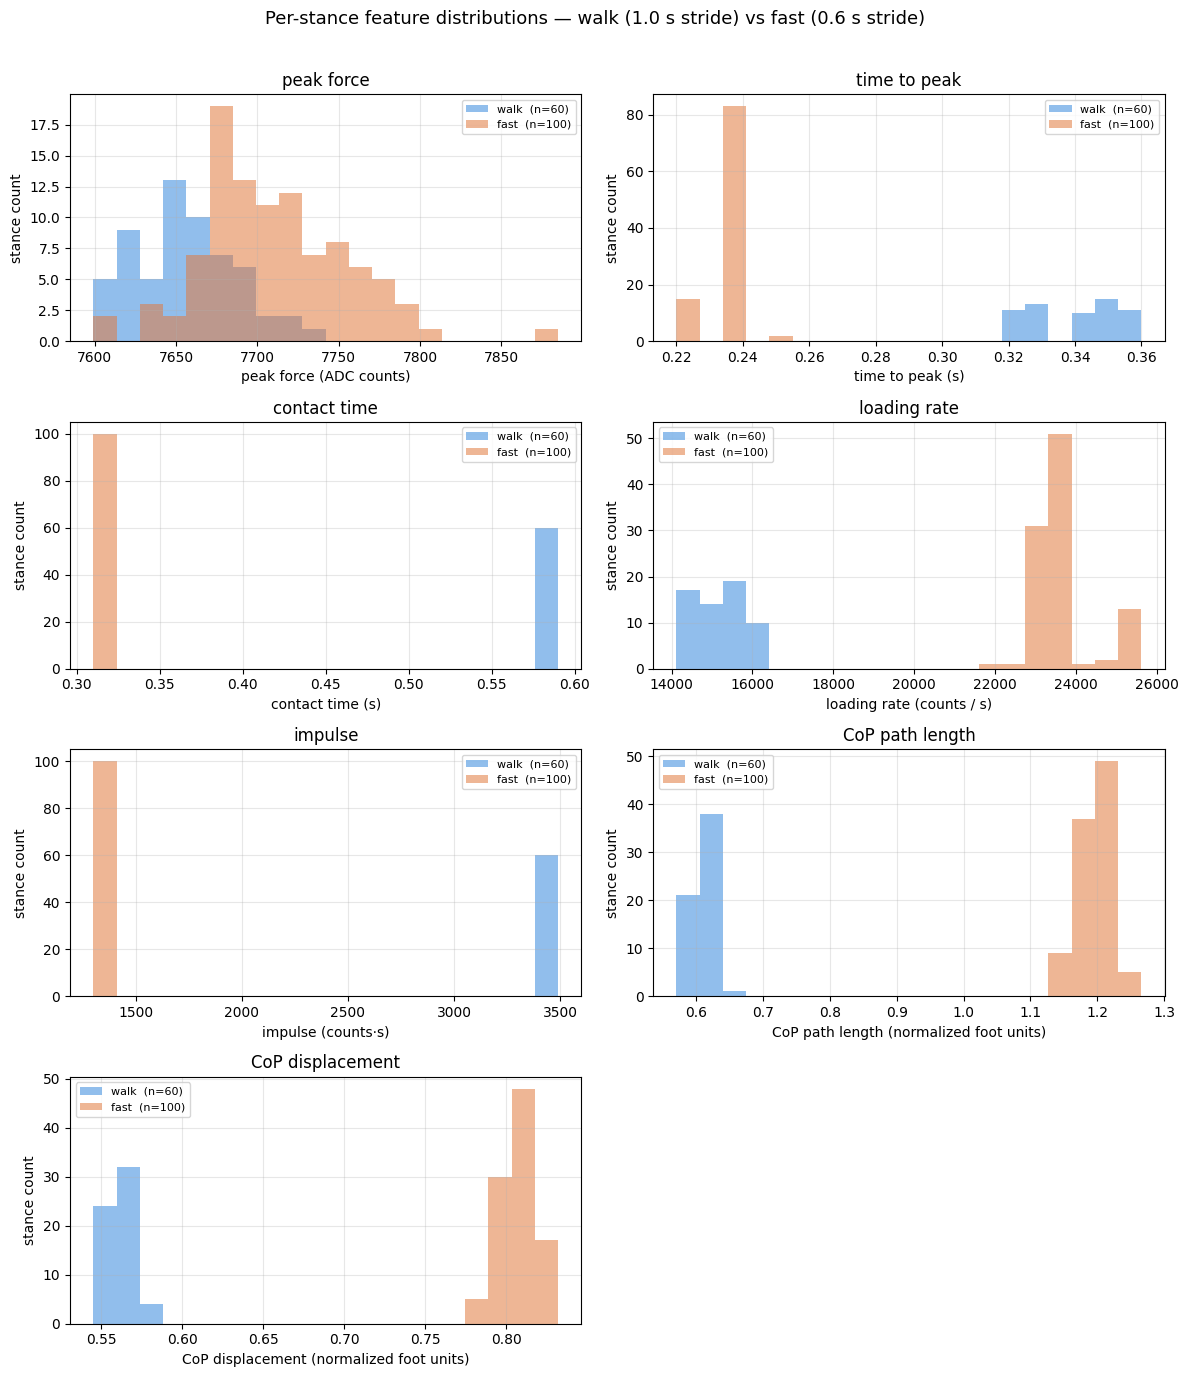

In [76]:
import matplotlib.pyplot as plt
import numpy as np

FEATURES = [
    ("peak_counts",      "peak force",      "ADC counts"),
    ("time_to_peak_s",   "time to peak",    "s"),
    ("contact_time_s",   "contact time",    "s"),
    ("loading_rate_cps", "loading rate",    "counts / s"),
    ("impulse_counts_s", "impulse",         "counts·s"),
    ("cop_path_len",     "CoP path length", "normalized foot units"),
    ("cop_displacement", "CoP displacement","normalized foot units"),
]

COLORS = {"walk": "#378ADD", "fast": "#E07A3F"}

fig, axes = plt.subplots(4, 2, figsize=(12, 14))

for ax, (col, nice_name, unit) in zip(axes.flat, FEATURES):
    series = all_feat[col].dropna()
    edges = np.histogram_bin_edges(series, bins=20)

    for label in ["walk", "fast"]:
        subset = all_feat.loc[all_feat["label"] == label, col].dropna()
        ax.hist(subset, bins=edges, alpha=0.55,
                color=COLORS[label], label=f"{label}  (n={len(subset)})")

    ax.set_title(nice_name)
    ax.set_xlabel(f"{nice_name} ({unit})")
    ax.set_ylabel("stance count")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

axes.flat[-1].axis("off")
fig.suptitle("Per-stance feature distributions - walk (1.0 s stride) vs fast (0.6 s stride)",
             fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])

In [78]:
import heatmap as H
out, dt = H.animate(cleaned, stances[0], cop_fn=cop_frame,
                    vmax=float(cleaned.iloc[stances[0][0]:stances[0][1]][SENSOR_COLS].to_numpy().max()))